In [2]:
from sysbrokers.IB.ib_connection import connectionIB
from sysbrokers.IB.ib_Fx_prices_data import ibFxPricesData

from ib_insync import util
util.startLoop()

Configuring sim logging


In [3]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
data = csvFuturesSimData()
data

csvFuturesSimData object with 252 instruments

In [4]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc

def calc_ewmac_forecast(price, Lfast, Lslow=None):
    price = price.resample("1B").last()
    if Lslow is None:
        Lslow = 4 * Lfast
    
    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma

    vol = robust_vol_calc(price.diff())

    return raw_ewmac / vol

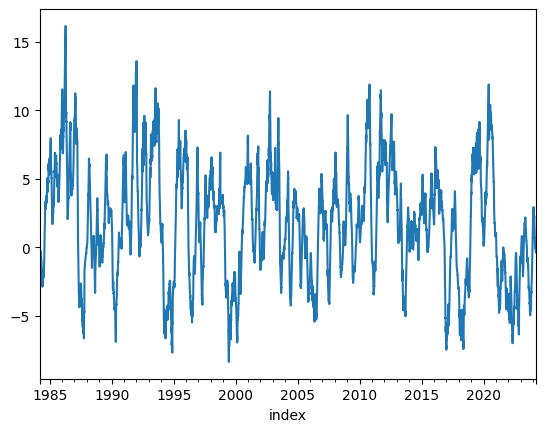

In [5]:
instrument_code = 'SOFR'
price=data.daily_prices(instrument_code)
ewmac=calc_ewmac_forecast(price, 32, 128)
ewmac.tail(5)

from matplotlib.pyplot import show
ewmac.plot()
show()

In [6]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast = ewmac, price=price)
account.percent.stats()

[[('min', '-5.81'),
  ('max', '5.141'),
  ('median', '0'),
  ('mean', '0.01263'),
  ('std', '0.4897'),
  ('skew', '-0.2253'),
  ('ann_mean', '3.232'),
  ('ann_std', '7.836'),
  ('sharpe', '0.4125'),
  ('sortino', '0.4848'),
  ('avg_drawdown', '-11.12'),
  ('time_in_drawdown', '0.9742'),
  ('calmar', '0.08974'),
  ('avg_return_to_drawdown', '0.2907'),
  ('avg_loss', '-0.3111'),
  ('avg_gain', '0.3172'),
  ('gaintolossratio', '1.019'),
  ('profitfactor', '1.092'),
  ('hitrate', '0.5173'),
  ('t_stat', '2.634'),
  ('p_value', '0.008446')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

<Axes: xlabel='index'>

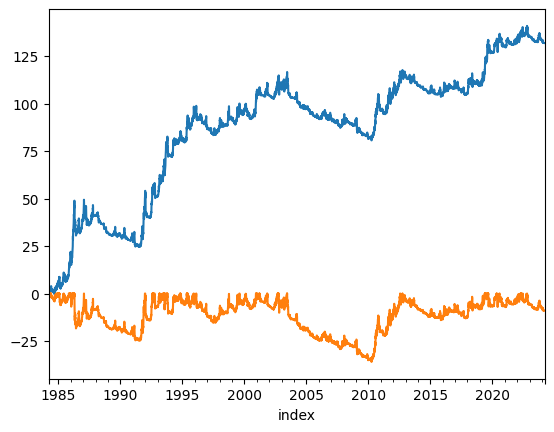

In [7]:
import syscore.pandas.strategy_functions

account.sharpe()
account.curve().plot()
account.percent
syscore.pandas.strategy_functions.drawdown(account.curve()).plot()

In [8]:
from systems.provided.rules.ewmac import ewmac_forecast_with_defaults as ewmac
from systems.forecasting import Rules
my_rules=Rules(dict(ewmac=ewmac))
my_rules.trading_rules()


{'ewmac': TradingRule; function: <function ewmac_forecast_with_defaults at 0x0000027CE4E9C5E0>, data: data.daily_prices (args: {}) and other_args: }

In [9]:
from systems.basesystem import System
my_system = System([my_rules], data)
my_system

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode


System base_system with .config, .data, and .stages: rules

In [10]:
my_system.rules.get_raw_forecast("SOFR", "ewmac").tail(5)

2025-08-01 14:33:55 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:33:55 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:33:55 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:33:55 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac


index
2024-03-22   -0.150546
2024-03-25   -0.164035
2024-03-26   -0.172350
2024-03-27   -0.167357
2024-03-28   -0.167032
Freq: B, Name: price, dtype: float64

In [11]:
from systems.trading_rules import TradingRule
ewmac_rule = TradingRule(ewmac)
my_rules = Rules(dict(ewmac=ewmac_rule))
ewmac_rule

TradingRule; function: <function ewmac_forecast_with_defaults at 0x0000027CE4E9C5E0>, data: data.daily_prices (args: {}) and other_args: 

In [12]:
ewmac_8 = TradingRule((ewmac, [], dict(Lfast=8, Lslow=32)))
ewmac_32 = TradingRule(dict(function=ewmac, other_args=dict(Lfast=32, Lslow=128)))
my_rules = Rules(dict(ewmac8=ewmac_8, ewmac32=ewmac_32))
my_rules.trading_rules()['ewmac32']

TradingRule; function: <function ewmac_forecast_with_defaults at 0x0000027CE4E9C5E0>, data: data.daily_prices (args: {}) and other_args: Lfast, Lslow

In [13]:
my_system = System([my_rules], data)
my_system.rules.get_raw_forecast("SOFR", "ewmac32").tail(5)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:33:56 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:33:56 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:33:56 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:33:56 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac32


index
2024-03-22   -0.150546
2024-03-25   -0.164035
2024-03-26   -0.172350
2024-03-27   -0.167357
2024-03-28   -0.167032
Freq: B, Name: price, dtype: float64

In [14]:
from sysdata.config.configdata import Config
my_config = Config()
my_config

Config with elements: 

In [15]:
empty_rules = Rules()
my_config.trading_rules = dict(ewmac8=ewmac_8, ewmac32=ewmac_32)
my_system = System([empty_rules], data, my_config)
print(my_system.rules.get_raw_forecast("SOFR", "ewmac8").tail(5))

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:33:56 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:33:56 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:33:56 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:33:56 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac8
index
2024-03-22   -0.341102
2024-03-25   -0.319042
2024-03-26   -0.283304
2024-03-27   -0.209219
2024-03-28   -0.168111
Freq: B, Name: price, dtype: float64


In [16]:
from systems.forecast_scale_cap import ForecastScaleCap

my_config.instruments = ["SOFR", "US10", "CORN", "SP500_micro"]

my_config.use_forecast_scale_estimates = True

fcs = ForecastScaleCap()
my_system = System([fcs, my_rules], data, my_config)
print(my_system.forecastScaleCap.get_forecast_scalar("SOFR", "ewmac32").tail(5))

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:33:56 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:33:56 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:33:56 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:33:56 DEBUG base_system {'stage': 'forecastScaleCap'} Getting cross sectional forecasts for scalar calculation for ewmac32 over CORN, SOFR, SP500_micro, US10
2025-08-01 14:33:56 DEBUG base_system {'stage': 'rules', 'instrument_code': 'CORN'} Calculating raw forecast CORN for ewmac32
2025-08-01 14:33:57 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac32
2025-08-01 14:33:57 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500_micro'} Calculating raw fo

In [17]:
from systems.forecast_combine import ForecastCombine

combiner = ForecastCombine()
my_system = System([fcs, empty_rules, combiner], data, my_config)
my_system.combForecast.get_forecast_weights("SOFR").tail(5)
my_system.combForecast.get_forecast_diversification_multiplier("SOFR").tail(5)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:33:58 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:33:58 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:33:58 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:33:58 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SOFR'} Calculating forecast weights for SOFR
2025-08-01 14:33:58 WARNING base_system {'stage': 'combForecast', 'instrument_code': 'SOFR'} WARNING: No forecast weights  - using equal weights of 0.500 over all 2 trading rules in system
2025-08-01 14:33:58 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SOFR'} Calculating capped forecast for SOFR ewmac32
2025-08-01 14:33:58 DEBUG base_system {'stage': 'rules', 'instrument_code':

index
2024-03-22    1.0
2024-03-25    1.0
2024-03-26    1.0
2024-03-27    1.0
2024-03-28    1.0
Freq: B, dtype: float64

In [18]:
from systems.rawdata import RawData
from systems.positionsizing import PositionSizing
from systems.accounts.accounts_stage import Account
combiner = ForecastCombine()
raw_data = RawData()
position_size = PositionSizing()
my_account = Account()

my_config.forecast_weight_estimate = dict(method = "one_period")
my_config.use_forecast_weight_estimates = True
my_config.use_forecat_div_mult_estimates = True

my_system = System([my_account, fcs, my_rules, combiner, position_size, raw_data], data, my_config)

print(my_system.combForecast.get_forecast_weights("SOFR").tail(5))
print(my_system.combForecast.get_forecast_diversification_multiplier("SOFR").tail(5))

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:34:00 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:34:00 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:34:00 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:34:00 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SOFR'} Calculating forecast weights for SOFR
2025-08-01 14:34:00 INFO base_system {'stage': 'combForecast', 'instrument_code': 'SOFR'} Calculating raw forecast weights for SOFR
2025-08-01 14:34:00 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'CORN'} Calculating capped forecast for CORN ewmac32
2025-08-01 14:34:00 DEBUG base_system {'stage': 'rules', 'instrument_code': 'CORN'} Calculating raw forecast CORN for ewmac32
2025-0

KeyboardInterrupt: 

In [40]:
my_config.forecast_weights=dict(ewmac8=0.5, ewmac32=0.5)
my_config.forecast_div_multiplier=1.1
my_config.use_forecast_weight_estimates = False
my_config.use_forecast_div_mult_estimates = False
my_system=System([fcs, empty_rules, combiner, raw_data, position_size], data, my_config)
my_system.combForecast.get_combined_forecast("SOFR").tail(5)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 13:58:08 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 13:58:08 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 13:58:08 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 13:58:08 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SOFR'} Calculating combined forecast for SOFR
2025-08-01 13:58:08 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SOFR'} Calculating capped forecast for SOFR ewmac32
2025-08-01 13:58:08 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac32
2025-08-01 13:58:08 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SOFR'} Getting cross sectional forecasts for scal

index
2024-03-22   -4.352534
2024-03-25   -4.182111
2024-03-26   -3.841267
2024-03-27   -3.028333
2024-03-28   -2.588955
Freq: B, dtype: float64

In [ ]:
my_config.percentage_vol_target = 25
my_config.notional_trading_capital = 100000
my_config.base_currency = 'USD'

my_system = System([fcs, empty_rules, combiner, position_size, raw_data], data, my_config)

my_system.positionSize.get_subsystem_position("SOFR").tail(5)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:13:43 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 


2025-08-01 14:13:43 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:13:43 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:13:43 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SOFR'} Calculating subsystem position for SOFR
2025-08-01 14:13:43 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SOFR'} Calculating volatility scalar for SOFR
2025-08-01 14:13:43 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SOFR'} Calculating instrument value vol for SOFR
2025-08-01 14:13:43 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SOFR'} Calculating instrument currency vol for SOFR
2025-08-01 14:13:43 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'SOFR'} Calculating daily volatility for SOFR
2025-08-01 14:13:43 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'SOFR'} Calculati

index
2024-03-22   -4.302536
2024-03-25   -4.178553
2024-03-26   -3.911908
2024-03-27   -3.118045
2024-03-28   -2.716880
Freq: B, dtype: float64

In [ ]:
from systems.portfolio import Portfolios
portfolio = Portfolios()

my_config.use_instrument_weight_estimates = True
my_config.use_forecast_div_mult_estimates = True
my_config.instrument_weight_estimate = dict(method='shrinkage', date_method='in_sample')

my_system = System([my_account, fcs, my_rules, combiner, position_size, raw_data, portfolio], data, my_config)

print(my_system.portfolio.get_instrument_weights())
print(my_system.portfolio.get_instrument_diversification_multiplier())

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:18:27 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 


2025-08-01 14:18:27 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:18:27 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:18:27 INFO base_system {'stage': 'portfolio'} Calculating instrument weights
2025-08-01 14:18:27 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:18:27 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:18:27 DEBUG base_system Following instruments are marked as 'bad_markets':  ['BAD_EXAMPLE']
2025-08-01 14:18:27 DEBUG base_system Following instruments have restricted trading:  ['RESTRICTED_EXAMPLE'] 
2025-08-01 14:18:27 DEBUG base_system Following instruments marked as not trading []
2025-08-01 14:18:27 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'CORN'} Calculating subsystem positi

In [46]:
my_config.instrument_weights=dict(US10=.1, SOFR=.4, CORN=.3, SP500_micro=.8)
my_config.instrument_div_multiplier=1.5
my_config.use_instrument_weight_estimates = False
my_config.use_instrument_div_mult_estimates = False

my_system=System([ fcs, empty_rules, combiner, position_size, raw_data, portfolio], data, my_config)

my_system.portfolio.get_notional_position("SOFR").tail(5)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:20:09 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:20:09 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:20:09 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:20:09 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating notional position for SOFR
2025-08-01 14:20:09 INFO base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating instrument weights
2025-08-01 14:20:09 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating raw instrument weights
2025-08-01 14:20:09 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:20:09 DEBUG base_system Following i

index
2024-03-22   -1.705293
2024-03-25   -1.656158
2024-03-26   -1.550479
2024-03-27   -1.235836
2024-03-28   -1.076838
Freq: B, dtype: float64

In [49]:
from systems.accounts.accounts_stage import Account

accounts = Account()
my_system = System([ fcs, empty_rules, combiner, position_size, raw_data, portfolio, accounts], data, my_config)
profits = my_system.accounts.portfolio()
profits.percent.stats()

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:25:54 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:25:54 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:25:54 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:25:54 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2025-08-01 14:25:54 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2025-08-01 14:25:54 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2025-08-01 14:25:54 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating notional position for CORN
2025-08-01 14:25:54 INFO base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating inst

[[('min', '-28.8'),
  ('max', '19'),
  ('median', '0.01186'),
  ('mean', '0.06392'),
  ('std', '2.102'),
  ('skew', '-0.3063'),
  ('ann_mean', '16.36'),
  ('ann_std', '33.63'),
  ('sharpe', '0.4866'),
  ('sortino', '0.6308'),
  ('avg_drawdown', '-29.42'),
  ('time_in_drawdown', '0.9715'),
  ('calmar', '0.18'),
  ('avg_return_to_drawdown', '0.5562'),
  ('avg_loss', '-1.389'),
  ('avg_gain', '1.451'),
  ('gaintolossratio', '1.045'),
  ('profitfactor', '1.096'),
  ('hitrate', '0.5119'),
  ('t_stat', '3.523'),
  ('p_value', '0.0004275')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

In [50]:
profits.gross.percent.stats()
profits.costs.percent.stats()

c:\Users\shumjeff\Dev\pysystemtrade\.venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\shumjeff\Dev\pysystemtrade\.venv\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[[('min', '-0.1232'),
  ('max', '0'),
  ('median', '-0.0007397'),
  ('mean', '-0.004239'),
  ('std', '0.007089'),
  ('skew', '-3.447'),
  ('ann_mean', '-1.085'),
  ('ann_std', '0.1134'),
  ('sharpe', '-9.568'),
  ('sortino', '-8.519'),
  ('avg_drawdown', '-29.37'),
  ('time_in_drawdown', '0.9998'),
  ('calmar', '-0.01909'),
  ('avg_return_to_drawdown', '-0.03695'),
  ('avg_loss', '-0.006882'),
  ('avg_gain', 'nan'),
  ('gaintolossratio', 'nan'),
  ('profitfactor', '0'),
  ('hitrate', '0'),
  ('t_stat', '-69.25'),
  ('p_value', '0')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

In [19]:
from systems.provided.example.simplesystem import simplesystem
my_system = simplesystem()
my_system

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode


System base_system with .config, .data, and .stages: accounts, portfolio, positionSize, combForecast, forecastScaleCap, rules, rawdata

In [20]:
my_system.portfolio.get_notional_position("SOFR").tail(5)

2025-08-01 14:34:28 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:34:28 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:34:28 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:34:28 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating notional position for SOFR
2025-08-01 14:34:28 INFO base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating instrument weights
2025-08-01 14:34:28 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating raw instrument weights
2025-08-01 14:34:28 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:34:28 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:34:28 DEBUG b

index
2024-03-22   -4.604817
2024-03-25   -4.425519
2024-03-26   -4.147973
2024-03-27   -3.336962
2024-03-28   -2.914016
Freq: B, dtype: float64

In [21]:
from sysdata.config.configdata import Config
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData

my_config = Config("systems.provided.example.simplesystemconfig.yaml")
my_data = csvFuturesSimData()

my_system = simplesystem(config=my_config, data=my_data)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode


In [22]:
from systems.provided.futures_chapter15.basesystem import futures_system
system = futures_system()
system.portfolio.get_notional_position("EUROSTX").tail(5)

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:39:52 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:39:52 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:39:52 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:39:52 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'EUROSTX'} Calculating notional position for EUROSTX
2025-08-01 14:39:52 INFO base_system {'stage': 'portfolio', 'instrument_code': 'EUROSTX'} Calculating instrument weights
2025-08-01 14:39:52 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'EUROSTX'} Calculating raw instrument weights
2025-08-01 14:39:52 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:39:52 DEBUG base_system

index
2024-03-22    5.122159
2024-03-25    5.285780
2024-03-26    5.385521
2024-03-27    5.451916
2024-03-28    5.518672
Freq: B, dtype: float64

In [24]:
from systems.provided.futures_chapter15.basesystem import futures_system

system = futures_system()
system.portfolio.get_notional_position("SOFR")

Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 14:52:38 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:52:38 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-08-01 14:52:38 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-08-01 14:52:38 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating notional position for SOFR
2025-08-01 14:52:38 INFO base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating instrument weights
2025-08-01 14:52:38 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating raw instrument weights
2025-08-01 14:52:38 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-08-01 14:52:38 DEBUG base_system Following i

index
1984-03-23         NaN
1984-03-26         NaN
1984-03-27         NaN
1984-03-28         NaN
1984-03-29         NaN
                ...   
2024-03-22   -0.525723
2024-03-25   -0.548660
2024-03-26   -0.569837
2024-03-27   -0.545828
2024-03-28   -0.553313
Freq: B, Length: 10440, dtype: float64

In [31]:
# Gist example of IB wrapper ...
#
# Download API from http://interactivebrokers.github.io/#
#
# Install python API code /IBJts/source/pythonclient $ python3 setup.py install
#
# Note: The test cases, and the documentation refer to a python package called IBApi,
#    but the actual package is called ibapi. Go figure.
#
# Get the latest version of the gateway:
# https://www.interactivebrokers.com/en/?f=%2Fen%2Fcontrol%2Fsystemstandalone-ibGateway.php%3Fos%3Dunix
#    (for unix: windows and mac users please find your own version)
#
# Run the gateway
#
# user: edemo
# pwd: demo123
#
# Now I'll try and replicate the time telling example


from ibapi.wrapper import EWrapper
from ibapi.client import EClient
from threading import Thread
import queue

class TestWrapper(EWrapper):
    """
    The wrapper deals with the action coming back from the IB gateway or TWS instance

    We override methods in EWrapper that will get called when this action happens, like currentTime


    """

    ## error handling code
    def init_error(self):
        error_queue=queue.Queue()
        self._my_errors = error_queue

    def get_error(self, timeout=5):
        if self.is_error():
            try:
                return self._my_errors.get(timeout=timeout)
            except queue.Empty:
                return None

        return None


    def is_error(self):
        an_error_if=not self._my_errors.empty()
        return an_error_if

    def error(self, id, errorTime, errorCode, errorString, advancedOrderRejectJson):
        ## Overriden method
        errormsg = "IB error id %d errorcode %d string %s" % (id, errorCode, errorString)
        self._my_errors.put(errormsg)

    ## Time telling code
    def init_time(self):
        time_queue=queue.Queue()
        self._time_queue = time_queue

        return time_queue

    def currentTime(self, time_from_server):
        ## Overriden method
        self._time_queue.put(time_from_server)


class TestClient(EClient):
    """
    The client method

    We don't override native methods, but instead call them from our own wrappers
    """
    def __init__(self, wrapper):
        ## Set up with a wrapper inside
        EClient.__init__(self, wrapper)

    def speaking_clock(self):
        """
        Basic example to tell the time

        :return: unix time, as an int
        """

        print("Getting the time from the server... ")

        ## Make a place to store the time we're going to return
        ## This is a queue
        time_storage=self.wrapper.init_time()

        ## This is the native method in EClient, asks the server to send us the time please
        self.reqCurrentTime()

        ## Try and get a valid time
        MAX_WAIT_SECONDS = 10

        try:
            current_time = time_storage.get(timeout=MAX_WAIT_SECONDS)
        except queue.Empty:
            print("Exceeded maximum wait for wrapper to respond")
            current_time = None

        while self.wrapper.is_error():
            print(self.get_error())

        return current_time

class TestApp(TestWrapper, TestClient):
    def __init__(self, ipaddress, portid, clientid):
        TestWrapper.__init__(self)
        TestClient.__init__(self, wrapper=self)

        self.connect(ipaddress, portid, clientid)

        thread = Thread(target = self.run)
        thread.start()

        setattr(self, "_thread", thread)

        self.init_error()


if __name__ == '__main__':
    ##
    ## Check that the port is the same as on the Gateway
    ## ipaddress is 127.0.0.1 if one same machine, clientid is arbitrary

    app = TestApp("127.0.0.1", 4001, 10)

    current_time = app.speaking_clock()

    print(current_time)

    app.disconnect()

2025-08-01 15:58:12 DEBUG ibapi.client 2736192325712 connState: None -> 0
2025-08-01 15:58:12 DEBUG ibapi.client 2736192325712 connState: None -> 0
2025-08-01 15:58:12 DEBUG ibapi.client 2736192325712 isConn: 0, connConnected: None
2025-08-01 15:58:12 DEBUG ibapi.client Connecting to 127.0.0.1:4001 w/ id:10
2025-08-01 15:58:12 DEBUG ibapi.client 2736192325712 connState: 0 -> 1
2025-08-01 15:58:12 DEBUG ibapi.client msg b'\x00\x00\x00\tv100..208'
2025-08-01 15:58:12 DEBUG ibapi.client REQUEST b'API\x00\x00\x00\x00\tv100..208'
2025-08-01 15:58:12 DEBUG ibapi.connection acquiring lock
2025-08-01 15:58:12 DEBUG ibapi.connection acquired lock
2025-08-01 15:58:12 DEBUG ibapi.connection releasing lock
2025-08-01 15:58:12 DEBUG ibapi.connection release lock
2025-08-01 15:58:12 DEBUG ibapi.connection sendMsg: sent: 17
2025-08-01 15:58:12 DEBUG ibapi.decoder Unset message id:0
2025-08-01 15:58:12 DEBUG ibapi.connection len 30 raw:b'\x00\x00\x00\x1a203\x0020250801 15:58:11 HKT\x00'|
2025-08-01 15

In [6]:
conn

NameError: name 'conn' is not defined

In [1]:
from sysbrokers.IB.ib_connection import connectionIB

conn = connectionIB(13, ib_ipaddress='127.0.0.1', ib_port=4001, account = 'DUM284189')

Configuring sim logging
Private configuration private/private_config.yaml does not exist; no problem if running in sim mode
2025-08-01 16:37:31 CRITICAL connectionIB {'type': 'connectionIB', 'broker': 'IB', 'clientid': 13} IB connection falied with exception - This event loop is already running, connection aborted.


RuntimeError: This event loop is already running

In [2]:
from sysobjects.contracts import futuresContract
from sysbrokers.IB.ib_futures_contract_price_data import ibFuturesContractPriceData
from sysdata.data_blob import dataBlob
ibfuturesdata = ibFuturesContractPriceData(conn, dataBlob())

ibfuturesdata.get_list_of_instrument_codes_with_merged_price_data() # returns list of instruments defined in [futures config file](/sysbrokers/IB/ibConfigFutures.csv)
ibfuturesdata.contract_dates_with_price_data_for_instrument_code("DAX") # returns list of contract dates
ibfuturesdata.get_prices_for_contract_object(futuresContract("DAX", "201203")) # returns OHLC price and volume data

NameError: name 'conn' is not defined